<img src="https://hilpisch.com/tpq_logo.png" alt="The Python Quants" width="35%" align="right" border="0"><br>

# Python for Finance (2nd ed.)

**Mastering Data-Driven Finance**

&copy; Dr. Yves J. Hilpisch | The Python Quants GmbH

<img src="https://hilpisch.com/images/py4fi_2nd_shadow.png" width="300px" align="left">

# Trading Strategies (b)

In [1]:
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib as mpl
# from pylab import mpl, plt
import warnings

In [2]:
warnings.simplefilter('ignore')
plt.style.use('seaborn-v0_8')
mpl.rcParams['font.family'] = 'serif'
np.random.seed(1000)
%config InlineBackend.figure_format = 'svg'

## Linear OLS Regression

### The Data

In [3]:
raw = pd.read_csv('tr_eikon_eod_data.csv',
                  index_col=0, parse_dates=True).dropna()

In [4]:
raw.columns

Index(['AAPL.O', 'MSFT.O', 'INTC.O', 'AMZN.O', 'GS.N', 'SPY', '.SPX', '.VIX',
       'EUR=', 'XAU=', 'GDX', 'GLD'],
      dtype='object')

In [5]:
symbol = 'EUR='

In [6]:
data = pd.DataFrame(raw[symbol])

In [7]:
data['returns'] = np.log(data / data.shift(1))

In [8]:
data.dropna(inplace=True)

In [9]:
data['direction'] = np.sign(data['returns']).astype(int)

In [10]:
data.head()

,EUR=,returns,direction
Date,,,
2010-01-05,1.4368,-0.002988,-1
2010-01-06,1.4412,0.003058,1
2010-01-07,1.4318,-0.006544,-1
2010-01-08,1.4412,0.006544,1
2010-01-11,1.4513,0.006984,1


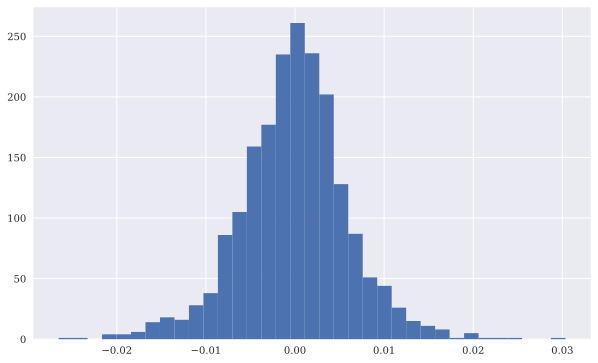

In [11]:
data['returns'].hist(bins=35, figsize=(10, 6));

In [12]:
lags = 2

In [13]:
def create_lags(data):
    global cols
    cols = []
    for lag in range(1, lags + 1):
        col = 'lag_{}'.format(lag)
        data[col] = data['returns'].shift(lag)
        cols.append(col)

In [14]:
create_lags(data)

In [15]:
data.head()

,EUR=,returns,direction,lag_1,lag_2
Date,,,,,
2010-01-05,1.4368,-0.002988,-1,NaN,NaN
2010-01-06,1.4412,0.003058,1,-0.002988,NaN
2010-01-07,1.4318,-0.006544,-1,0.003058,-0.002988
2010-01-08,1.4412,0.006544,1,-0.006544,0.003058
2010-01-11,1.4513,0.006984,1,0.006544,-0.006544


In [16]:
data.dropna(inplace=True)

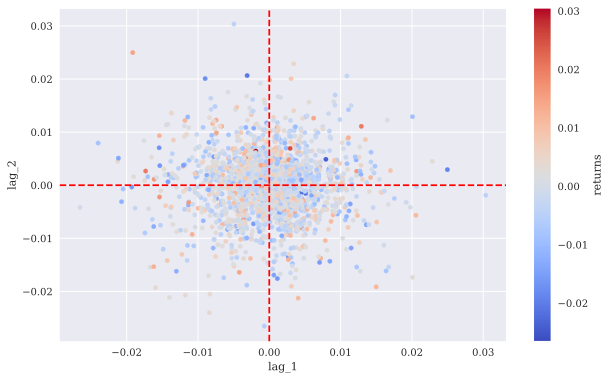

In [17]:
data.plot.scatter(x='lag_1', y='lag_2', c='returns', 
                  cmap='coolwarm', figsize=(10, 6), colorbar=True)
plt.axvline(0, c='r', ls='--')
plt.axhline(0, c='r', ls='--');

### Regression

In [20]:
from sklearn.linear_model import LinearRegression  

In [21]:
model = LinearRegression()  

In [22]:
data['pos_ols_1'] = model.fit(data[cols], data['returns']).predict(data[cols])  

In [23]:
data['pos_ols_2'] = model.fit(data[cols], data['direction']).predict(data[cols])  

In [24]:
data[['pos_ols_1', 'pos_ols_2']].head()

,pos_ols_1,pos_ols_2
Date,,
2010-01-07,-0.000202,-0.004063
2010-01-08,0.000046,0.043384
2010-01-11,-0.000310,-0.019115
2010-01-12,-0.000143,-0.042655
2010-01-13,0.000007,0.005976


In [25]:
data[['pos_ols_1', 'pos_ols_2']] = np.where(
            data[['pos_ols_1', 'pos_ols_2']] > 0, 1, -1)  

In [26]:
data['pos_ols_1'].value_counts()  

pos_ols_1
-1    1605
 1     364
Name: count, dtype: int64

In [27]:
data['pos_ols_2'].value_counts()  

pos_ols_2
 1    1231
-1     738
Name: count, dtype: int64

In [28]:
(data['pos_ols_1'].diff() != 0).sum()  

np.int64(701)

In [29]:
(data['pos_ols_2'].diff() != 0).sum()  

np.int64(789)

In [30]:
data['strat_ols_1'] = data['pos_ols_1'] * data['returns']

In [31]:
data['strat_ols_2'] = data['pos_ols_2'] * data['returns']

In [32]:
data[['returns', 'strat_ols_1', 'strat_ols_2']].sum().apply(np.exp)

returns        0.807938
strat_ols_1    1.345052
strat_ols_2    1.418594
dtype: float64

In [33]:
(data['direction'] == data['pos_ols_1']).value_counts()  

True     989
False    980
Name: count, dtype: int64

In [34]:
(data['direction'] == data['pos_ols_2']).value_counts()  

True     1023
False     946
Name: count, dtype: int64

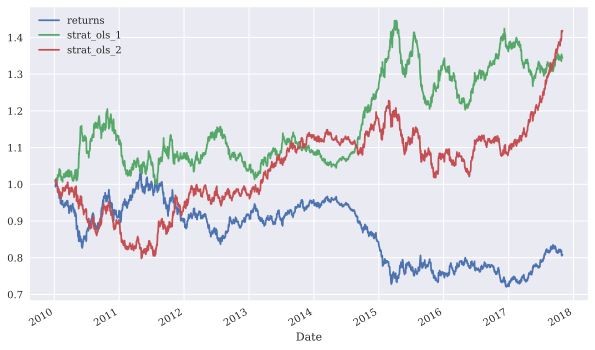

In [35]:
data[['returns', 'strat_ols_1', 'strat_ols_2']].cumsum(
        ).apply(np.exp).plot(figsize=(10, 6));

## Clustering

In [36]:
from sklearn.cluster import KMeans

In [37]:
model = KMeans(n_clusters=2, random_state=0)  #  <1>

In [38]:
model.fit(data[cols])

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [39]:
data['pos_clus'] = model.predict(data[cols])

In [40]:
data['pos_clus'] = np.where(data['pos_clus'] == 1, -1, 1)  

In [41]:
data['pos_clus'].values

array([ 1, -1,  1, ..., -1,  1,  1], shape=(1969,))

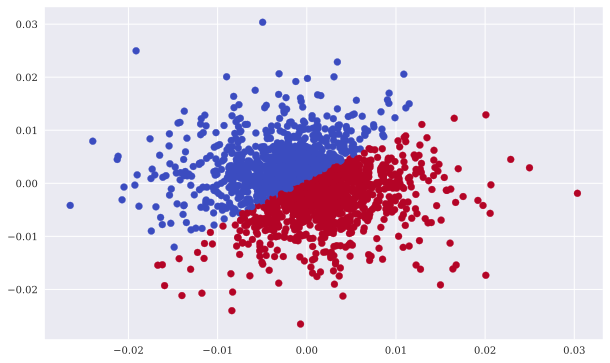

In [42]:
plt.figure(figsize=(10, 6))
plt.scatter(data[cols].iloc[:, 0], data[cols].iloc[:, 1],
            c=data['pos_clus'], cmap='coolwarm');

In [43]:
data['strat_clus'] = data['pos_clus'] * data['returns']

In [44]:
data[['returns', 'strat_clus']].sum().apply(np.exp)

returns       0.807938
strat_clus    0.764502
dtype: float64

In [45]:
(data['direction'] == data['pos_clus']).value_counts()

False    1005
True      964
Name: count, dtype: int64

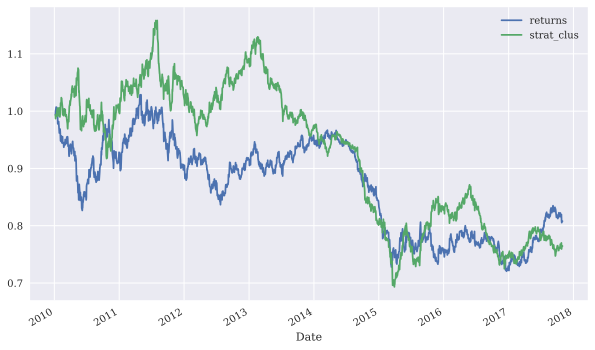

In [46]:
data[['returns', 'strat_clus']].cumsum().apply(np.exp).plot(figsize=(10, 6));

## Frequency Approach

In [47]:
def create_bins(data, bins=[0]):
    global cols_bin
    cols_bin = []
    for col in cols:
        col_bin = col + '_bin'
        data[col_bin] = np.digitize(data[col], bins=bins)  
        cols_bin.append(col_bin)

In [48]:
create_bins(data)

In [49]:
data[cols_bin + ['direction']].head()  

,lag_1_bin,lag_2_bin,direction
Date,,,
2010-01-07,1,0,-1
2010-01-08,0,1,1
2010-01-11,1,0,1
2010-01-12,1,1,-1
2010-01-13,0,1,1


In [50]:
grouped = data.groupby(cols_bin + ['direction'])
grouped.size()  

lag_1_bin  lag_2_bin  direction
0          0          -1           221
                       0             4
                       1           236
           1          -1           240
                       1           268
1          0          -1           250
                       0             1
                       1           258
           1          -1           259
                       0             4
                       1           228
dtype: int64

In [51]:
res = grouped['direction'].size().unstack(fill_value=0)  

In [52]:
def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: yellow' if v else '' for v in is_max]  

In [53]:
res.style.apply(highlight_max, axis=1)  

In [54]:
data['pos_freq'] = np.where(data[cols_bin].sum(axis=1) == 2, -1, 1)  

In [55]:
(data['direction'] == data['pos_freq']).value_counts()

True     1021
False     948
Name: count, dtype: int64

In [56]:
data['strat_freq'] = data['pos_freq'] * data['returns']

In [57]:
data[['returns', 'strat_freq']].sum().apply(np.exp)

returns       0.807938
strat_freq    1.087601
dtype: float64

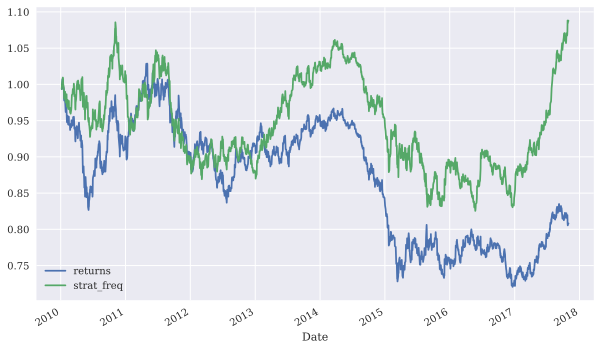

In [58]:
data[['returns', 'strat_freq']].cumsum().apply(np.exp).plot(figsize=(10, 6));

## Classification Algorithms

In [59]:
from sklearn import linear_model
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

In [60]:
C = 1

In [61]:
models = {
    'log_reg': linear_model.LogisticRegression(C=C),
    'gauss_nb': GaussianNB(),
    'svm': SVC(C=C)
}

In [62]:
def fit_models(data):  
    mfit = {model: models[model].fit(data[cols_bin], data['direction'])
            for model in models.keys()} 

In [63]:
fit_models(data)

In [64]:
def derive_positions(data):  
    for model in models.keys():
        data['pos_' + model] = models[model].predict(data[cols_bin])

In [65]:
derive_positions(data)

In [66]:
def evaluate_strats(data):  
    global sel
    sel = []
    for model in models.keys():
        col = 'strat_' + model 
        data[col] = data['pos_' + model] * data['returns']
        sel.append(col)
    sel.insert(0, 'returns')

In [67]:
evaluate_strats(data)

In [68]:
sel.insert(1, 'strat_freq')

In [69]:
data[sel].sum().apply(np.exp)  

returns           0.807938
strat_freq        1.087601
strat_log_reg     1.320000
strat_gauss_nb    1.320000
strat_svm         1.087601
dtype: float64

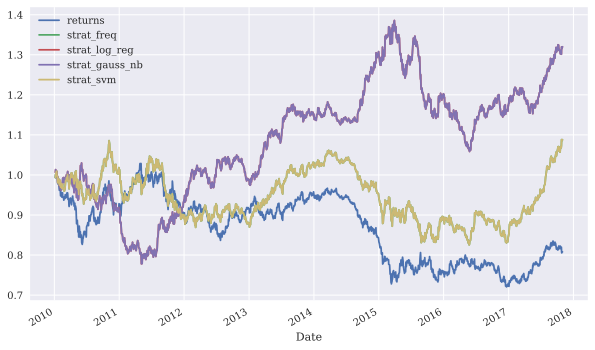

In [70]:
data[sel].cumsum().apply(np.exp).plot(figsize=(10, 6));

In [71]:
data = pd.DataFrame(raw[symbol])

In [72]:
data['returns'] = np.log(data / data.shift(1))

In [73]:
data['direction'] = np.sign(data['returns'])

In [74]:
lags = 5  
create_lags(data)
data.dropna(inplace=True)

In [75]:
create_bins(data)  
cols_bin

['lag_1_bin', 'lag_2_bin', 'lag_3_bin', 'lag_4_bin', 'lag_5_bin']

In [76]:
data[cols_bin].head()

,lag_1_bin,lag_2_bin,lag_3_bin,lag_4_bin,lag_5_bin
Date,,,,,
2010-01-12,1,1,0,1,0
2010-01-13,0,1,1,0,1
2010-01-14,1,0,1,1,0
2010-01-15,0,1,0,1,1
2010-01-19,0,0,1,0,1


In [77]:
data.dropna(inplace=True)

In [78]:
fit_models(data)

In [79]:
derive_positions(data)

In [80]:
evaluate_strats(data)

In [81]:
data[sel].sum().apply(np.exp)

returns           0.802315
strat_log_reg     1.124849
strat_gauss_nb    1.124849
strat_svm         2.650562
dtype: float64

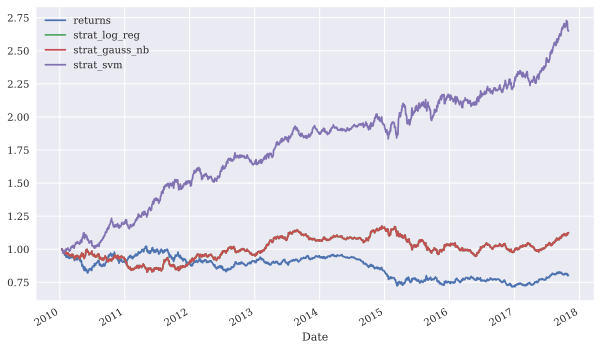

In [82]:
data[sel].cumsum().apply(np.exp).plot(figsize=(10, 6));

In [83]:
mu = data['returns'].mean()  
v = data['returns'].std()  

In [84]:
bins = [mu - v, mu, mu + v]  
bins  

[np.float64(-0.006138954541842338),
 np.float64(-0.00011203142095872083),
 np.float64(0.005914891699924897)]

In [85]:
create_bins(data, bins)

In [86]:
data[cols_bin].head()

,lag_1_bin,lag_2_bin,lag_3_bin,lag_4_bin,lag_5_bin
Date,,,,,
2010-01-12,3,3,0,2,1
2010-01-13,1,3,3,0,2
2010-01-14,2,1,3,3,0
2010-01-15,1,2,1,3,3
2010-01-19,0,1,2,1,3


In [87]:
fit_models(data)

In [88]:
derive_positions(data)

In [89]:
evaluate_strats(data)

In [90]:
data[sel].sum().apply(np.exp)

returns           0.802315
strat_log_reg     1.282427
strat_gauss_nb    1.341964
strat_svm         5.877609
dtype: float64

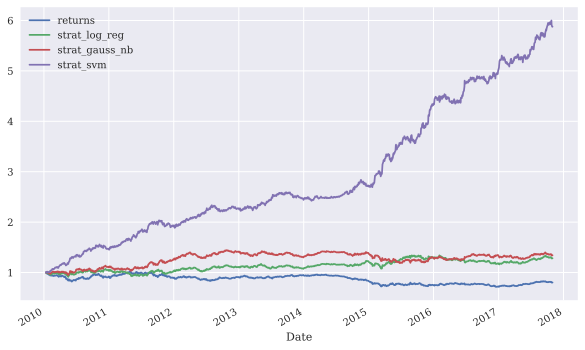

In [91]:
data[sel].cumsum().apply(np.exp).plot(figsize=(10, 6));

### Sequential Train-Test Split

In [92]:
split = int(len(data) * 0.5)

In [93]:
train = data.iloc[:split].copy()  

In [94]:
fit_models(train)  

In [95]:
test = data.iloc[split:].copy()  

In [96]:
derive_positions(test)  

In [97]:
evaluate_strats(test)  

In [98]:
test[sel].sum().apply(np.exp)

returns           0.851979
strat_log_reg     0.943480
strat_gauss_nb    0.911414
strat_svm         0.919531
dtype: float64

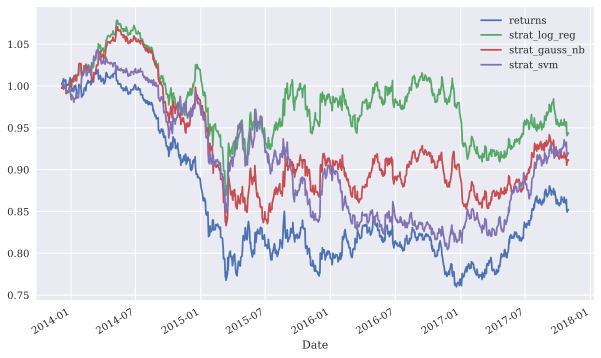

In [99]:
test[sel].cumsum().apply(np.exp).plot(figsize=(10, 6));

### Randomized Train-Test Split

In [100]:
from sklearn.model_selection import train_test_split

In [101]:
train, test = train_test_split(data, test_size=0.5,
                               shuffle=True, random_state=100)

In [102]:
train = train.copy().sort_index()  

In [103]:
train[cols_bin].head()

,lag_1_bin,lag_2_bin,lag_3_bin,lag_4_bin,lag_5_bin
Date,,,,,
2010-01-12,3,3,0,2,1
2010-01-13,1,3,3,0,2
2010-01-14,2,1,3,3,0
2010-01-15,1,2,1,3,3
2010-01-20,1,0,1,2,1


In [104]:
test = test.copy().sort_index()  

In [105]:
fit_models(train)

In [106]:
derive_positions(test)

In [107]:
evaluate_strats(test)

In [108]:
test[sel].sum().apply(np.exp)

returns           0.847855
strat_log_reg     0.981150
strat_gauss_nb    1.102309
strat_svm         0.948384
dtype: float64

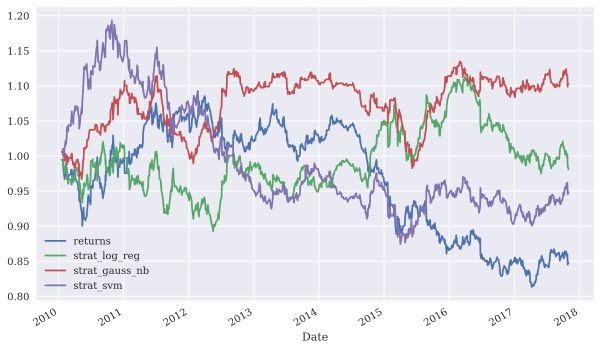

In [109]:
test[sel].cumsum().apply(np.exp).plot(figsize=(10, 6));

## Deep Neural Network

### DNN with scikit-learn

In [110]:
from sklearn.neural_network import MLPClassifier

In [111]:
model = MLPClassifier(solver='lbfgs', alpha=1e-5,
                     hidden_layer_sizes=2 * [250], random_state=1)

In [112]:
%time model.fit(data[cols_bin], data['direction'])

CPU times: total: 36.1 s
Wall time: 4.71 s


,hidden_layer_sizes,"[250, 250]"
,activation,'relu'
,solver,'lbfgs'
,alpha,1e-05
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,200
,shuffle,True
,random_state,1


In [113]:
data['pos_dnn_sk'] = model.predict(data[cols_bin])

In [114]:
data['strat_dnn_sk'] = data['pos_dnn_sk'] * data['returns']

In [115]:
data[['returns', 'strat_dnn_sk']].sum().apply(np.exp)

returns          0.802315
strat_dnn_sk    55.851367
dtype: float64

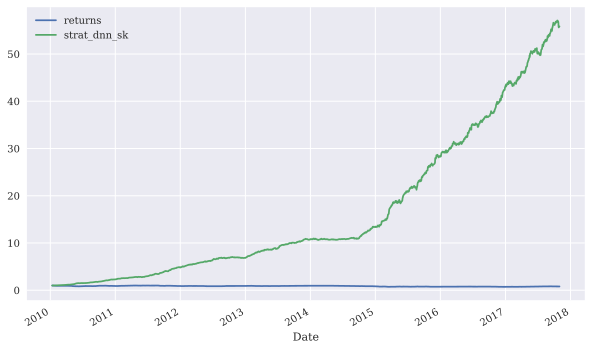

In [116]:
data[['returns', 'strat_dnn_sk']].cumsum().apply(np.exp).plot(figsize=(10, 6));

In [117]:
train, test = train_test_split(data, test_size=0.5, random_state=100)

In [118]:
train = train.copy().sort_index()

In [119]:
test = test.copy().sort_index()

In [120]:
model = MLPClassifier(solver='lbfgs', alpha=1e-5, max_iter=500,
                     hidden_layer_sizes=3 * [500], random_state=1)  

In [121]:
%time model.fit(train[cols_bin], train['direction'])

CPU times: total: 5min 56s
Wall time: 45.1 s


,hidden_layer_sizes,"[500, 500, ...]"
,activation,'relu'
,solver,'lbfgs'
,alpha,1e-05
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,500
,shuffle,True
,random_state,1


In [122]:
test['pos_dnn_sk'] = model.predict(test[cols_bin])

In [123]:
test['strat_dnn_sk'] = test['pos_dnn_sk'] * test['returns']

In [124]:
test[['returns', 'strat_dnn_sk']].sum().apply(np.exp)

returns         0.847855
strat_dnn_sk    1.094880
dtype: float64

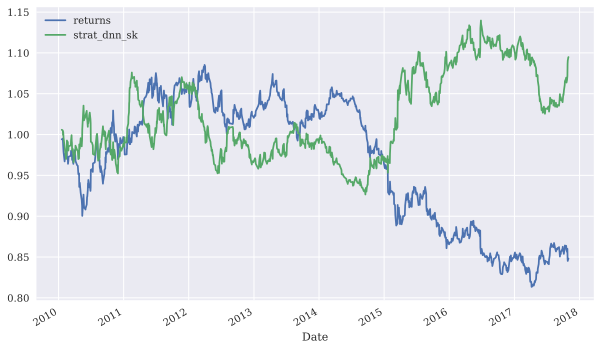

In [125]:
test[['returns', 'strat_dnn_sk']].cumsum().apply(np.exp).plot(figsize=(10, 6));

### DNN with Keras & TensorFlow Backend

In [126]:
import tensorflow as tf
from keras.layers import Dense
from keras.models import Sequential

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
def create_model():
    np.random.seed(100)
    tf.random.set_seed(100)
    model = Sequential()
    model.add(Dense(16, activation='relu', input_dim=lags))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='rmsprop',
                  metrics=['accuracy'])
    return model

In [ ]:
data_ = (data - data.mean()) / data.std()
data['direction_'] = np.where(data['direction'] == 1, 1, 0)

In [ ]:
model = create_model()

In [ ]:
%%time
model.fit(data_[cols], data['direction_'],
          epochs=50, verbose=False)

In [ ]:
model.evaluate(data_[cols], data['direction_'])

In [ ]:
pred = np.where(model.predict(data_[cols]) > 0.5, 1, 0) 
pred[:10].flatten()

In [ ]:
data['pos_dnn_ke'] = np.where(pred > 0, 1, -1)  

In [ ]:
data['strat_dnn_ke'] = data['pos_dnn_ke'] * data['returns']

In [ ]:
data[['returns', 'strat_dnn_ke']].sum().apply(np.exp)

In [ ]:
data[['returns', 'strat_dnn_ke']].cumsum(
        ).apply(np.exp).plot(figsize=(10, 6));

In [ ]:
mu, std = train.mean(), train.std()

In [ ]:
train_ = (train - mu) / mu.std()

In [ ]:
model = create_model()

In [ ]:
train['direction_'] = np.where(train['direction'] > 0, 1, 0)

In [ ]:
%%time
model.fit(train_[cols], train['direction_'],
          epochs=50, verbose=False)

In [ ]:
test_ = (test - mu) / std

In [ ]:
test['direction_'] = np.where(test['direction'] > 0, 1, 0)

In [ ]:
model.evaluate(test_[cols], test['direction_'])

In [ ]:
pred = np.where(model.predict(test_[cols]) > 0.5, 1, 0) 
pred[:10].flatten()

In [ ]:
test['pos_dnn_ke'] = np.where(pred > 0, 1, -1)

In [ ]:
test['strat_dnn_ke'] = test['pos_dnn_ke'] * test['returns']

In [ ]:
test[['returns', 'strat_dnn_sk', 'strat_dnn_ke']].sum().apply(np.exp)

In [ ]:
test[['returns', 'strat_dnn_sk', 'strat_dnn_ke']].cumsum(
        ).apply(np.exp).plot(figsize=(10, 6));

<img src="https://hilpisch.com/tpq_logo.png" alt="The Python Quants" width="35%" align="right" border="0"><br>

<a href="https://tpq.io" target="_blank">https://tpq.io</a> | <a href="https://twitter.com/dyjh" target="_blank">@dyjh</a> | <a href="mailto:training@tpq.io">training@tpq.io</a>